Adding for packages



#1. Import libraries



In [249]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#ica05
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, OneHotEncoder
#ica06
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
#ica07
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.model_selection import train_test_split
#ica08
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
#ica09
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree

#Load and inspect the data

In [74]:
#load
train_df = pd.read_csv('listings_train.csv')
test_df = pd.read_csv('listings_test_features.csv')

#displaying the training/test data
print("\n ----- Training data: ------\n")
display(train_df.head())
print("\n ----- Test data: ------\n")
display(test_df.head())



Training shape: (42234, 36)
Test shape: (8199, 35)

 ----- Training data: ------



,id,name,host_id,host_name,host_total_listings_count,host_has_profile_pic,host_identity_verified,neighbourhood_group,neighbourhood,latitude,longitude,room_type,minimum_nights,calculated_host_listings_count,availability_365,number_of_reviews_ltm,accommodates,bathrooms,bedrooms,beds,amenities,availability_30,availability_60,availability_90,number_of_reviews,last_review,reviews_per_month,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,price
0,8.637189e+17,One bedroom modern flat stunning central London,508846510,Lin,1.0,t,t,NaN,Hammersmith and Fulham,51.473060,-0.183720,Entire home/apt,2,1,1,6,2,1.5,1.0,1.0,"[""Clothing storage: wardrobe"", ""Self check-in""...",0,0,0,31,2025-06-01,1.06,4.71,4.71,4.58,4.65,4.87,4.77,4.65,NaN,104
1,1.246273e+18,Modern 1BR Flat in Central Brixton – Asaph House,229912595,Nicole,23.0,t,t,NaN,Lambeth,51.461770,-0.121320,Entire home/apt,28,15,319,3,4,1.0,1.0,2.0,"[""Kitchen"", ""Cleaning products"", ""Smoke alarm""...",30,60,90,3,2025-04-16,0.32,5.00,5.00,5.00,5.00,5.00,5.00,5.00,NaN,219
2,9.958368e+17,Suite-Deluxe-Ensuite-Street View-6,491436321,Ada Leo,26.0,t,t,NaN,Hackney,51.545587,-0.058349,Private room,1,25,365,4,3,1.0,1.0,2.0,"[""Clothing storage: wardrobe"", ""Safe"", ""HDTV w...",30,60,90,4,2025-07-21,0.86,4.00,4.25,4.00,4.25,4.50,4.00,4.00,NaN,96
3,8.884977e+17,Single Room with shared bathroom in central Lo...,513462549,Manor,4.0,f,t,NaN,Kensington and Chelsea,51.492899,-0.195460,Private room,1,4,270,0,1,1.0,6.0,6.0,"[""Essentials"", ""TV"", ""Cleaning products"", ""Fir...",30,60,90,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,200
4,1.069328e+18,Canary Wharf Retreat with Free Secure Parking,1432477,Maxime,791.0,t,t,NaN,Tower Hamlets,51.498470,-0.013030,Entire home/apt,1,252,354,6,4,2.0,2.0,2.0,"[""Self check-in"", ""Kitchen"", ""Smoke alarm"", ""D...",19,49,79,17,2025-07-20,0.87,4.82,4.82,5.00,4.65,4.88,4.88,4.82,NaN,261



 ----- Test data: ------



,id,name,host_id,host_name,host_total_listings_count,host_has_profile_pic,host_identity_verified,neighbourhood_group,neighbourhood,latitude,longitude,room_type,minimum_nights,calculated_host_listings_count,availability_365,number_of_reviews_ltm,accommodates,bathrooms,bedrooms,beds,amenities,availability_30,availability_60,availability_90,number_of_reviews,last_review,reviews_per_month,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license
0,1.136690e+18,chill flat,81356851,Sylwia,1,t,f,NaN,Barnet,51.626248,-0.141629,Entire home/apt,5,1,206,2,6,2.0,3,3,"[""Kitchen"", ""Outdoor dining area"", ""HDTV with ...",0,0,0,4,2025-07-20,0.30,5.00,5.00,5.00,4.75,5.00,5.00,5.00,NaN
1,6.919139e+06,2014 VW Camper called Viv,7724775,Jenna,1,t,t,NaN,Lewisham,51.428070,-0.056650,Entire home/apt,2,1,364,0,2,0.0,0,1,"[""Coffee maker"", ""Kitchen"", ""Dishes and silver...",29,59,89,9,2024-08-19,0.09,5.00,5.00,4.89,5.00,5.00,5.00,5.00,NaN
2,1.376724e+18,Elegant City Stay steps to Oxford Street,594523926,Fabio,12,t,t,NaN,Camden,51.520461,-0.136611,Entire home/apt,5,12,271,3,5,1.0,2,3,"[""Kitchen"", ""Cleaning products"", ""Smoke alarm""...",3,21,35,3,2025-07-02,0.68,3.33,4.00,3.67,4.00,3.67,4.00,3.33,NaN
3,1.365046e+18,Indigo Flats Chic Apartment 2 West End,29024847,Sarah,96,t,t,NaN,Westminster,51.513179,-0.135828,Entire home/apt,3,44,288,1,4,1.0,1,2,"[""Self check-in"", ""Kitchen"", ""Shampoo"", ""High ...",7,18,31,1,2025-07-14,0.46,5.00,5.00,5.00,5.00,5.00,5.00,5.00,NaN
4,1.385436e+18,Holloway 3-BR flat w. Private Patio near Camden,661844715,Anna,49,t,t,NaN,Islington,51.551530,-0.122166,Entire home/apt,1,21,301,14,10,2.0,3,5,"[""Kitchen"", ""Cleaning products"", ""Outdoor dini...",13,28,46,14,2025-09-08,3.28,4.71,4.64,4.57,4.57,4.71,4.79,4.79,NaN


# EDA



**0.   Framing**
--
What type of problem is this — supervised /unsupervised? Classification,clustering, regression?

This is a supervised learning problem, every training row comes with a known answer label, (price) and the target is a numeric value which makes this a regression.



In [60]:

#getting summaries
train_df.info()

#showing target price frm training data
train_df["price"].head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42234 entries, 0 to 42233
Data columns (total 36 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              42234 non-null  float64
 1   name                            42234 non-null  object 
 2   host_id                         42234 non-null  int64  
 3   host_name                       42216 non-null  object 
 4   host_total_listings_count       42218 non-null  float64
 5   host_has_profile_pic            42218 non-null  object 
 6   host_identity_verified          42218 non-null  object 
 7   neighbourhood_group             0 non-null      float64
 8   neighbourhood                   42234 non-null  object 
 9   latitude                        42234 non-null  float64
 10  longitude                       42234 non-null  float64
 11  room_type                       42234 non-null  object 
 12  minimum_nights                  

,price
0,104
1,219
2,96
3,200
4,261




**1: Data Quality **
--
*  How many columns are there in the training set?

    There is 36 columns in the training set
*  How many in the test set?

    Theres 35 columns in the test set
*   How many rows are there in the training set?

    there is 42234 rows in training set
*   How many in the test set?

    Theres 8199 rows in test

In [75]:
#printing sahpe of files
print("Training shape:", train_df.shape)
print("Test shape:", test_df.shape)


Training shape: (42234, 36)
Test shape: (8199, 35)


* Where do they match /
mismatch? Which contain missing values?

The test has price but not the training as we know. both test and trainign are missing all data for neighbourhood_group and license.
The test set has no missing values outside the two dead columns



In [76]:
# removing all columns that both training and test
train_only_columns = set(train_df.columns) - set(test_df.columns)
test_only_columns = set(test_df.columns) - set(train_df.columns)
#printing missing info per columns in each
print("Columns only in train:", train_only_columns)
print("Columns only in test:", test_only_columns)

#checking every column that has at least one missing value in either file
missing_summary = pd.DataFrame({
    "train_missing": train_df.isna().sum(),
    "test_missing": test_df.isna().sum().reindex(train_df.columns)})
missing_summary = missing_summary[missing_summary.sum(axis=1) > 0]
display(missing_summary)


Columns only in train: {'price'}
Columns only in test: set()


,train_missing,test_missing
host_name,18,0.0
host_total_listings_count,16,0.0
host_has_profile_pic,16,0.0
host_identity_verified,16,0.0
neighbourhood_group,42234,8199.0
bathrooms,42,0.0
bedrooms,47,0.0
beds,80,0.0
last_review,9135,0.0
reviews_per_month,9135,0.0


* How many are usable
as is?

About 33,015 of the 42,234 training rows are usable exactly as-is and all 8,199 data from test

In [78]:
#dropping all data taht equates to NaN to get usable data
usable_train_rows = train_df.dropna(axis=1, how="all").dropna().shape[0]
usable_test_rows = test_df.dropna(axis=1, how="all").dropna().shape[0]

print(f"Train rows with no missing values (ignoring all-NaN columns): "
      f"{usable_train_rows} of {len(train_df)}")
print(f"Test rows with no missing values (ignoring all-NaN columns):  "
      f"{usable_test_rows} of {len(test_df)}")

Train rows with no missing values (ignoring all-NaN columns): 33015 of 42234
Test rows with no missing values (ignoring all-NaN columns):  8199 of 8199


**2. Distributions**
--

Is price normally distributed?

The price is not normally distributed it is right skewed (skewness shown 1.18, mean $166 and the median $141) and it is bounded to $50–$500.

What is the
median price?

Median price: $141.00


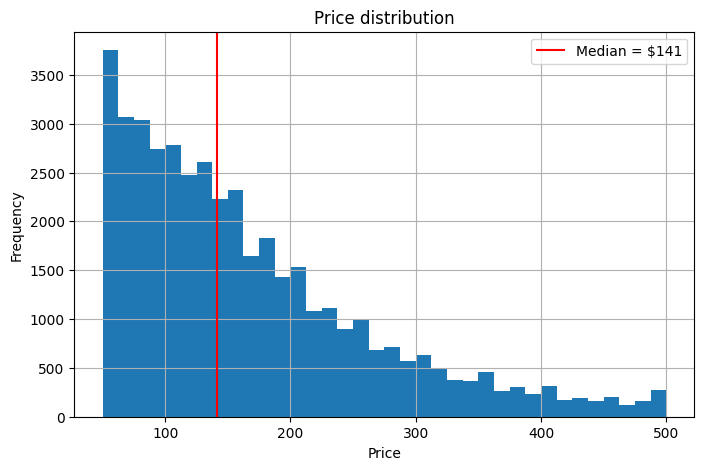

Median price: $141.00
Mean price:   $166.24
Skewness:     1.18
Min / Max:    $50 / $500


In [111]:
from sklearn.base import OutlierMixin
#hint Consider a histplot for this.

#getting median price
median_price = train_df["price"].median()
#starting plot (histplot)
plt.figure(figsize=(8, 5))
train_df["price"].hist(bins=36)
#adding median plt as a line to stand out
plt.axvline(median_price, color="red",label=f"Median = ${median_price:.0f}")
plt.title("Price distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.legend()
plt.show()
#printing info meadian mean and skew
print(f"Median price: ${median_price:.2f}")
print(f"Mean price:   ${train_df['price'].mean():.2f}")
print(f"Skewness:     {train_df['price'].skew():.2f}")
#get min and max for bounds of data
print(f"Min / Max:    ${train_df['price'].min()} / ${train_df['price'].max()}")


How are features distributed —
normally / not normally?

The features are not normal either — minimum_nights and the review counts are heavily skewed towards the right, availability_365 piles up at 0 and 365, and the review scores bunch up <100.


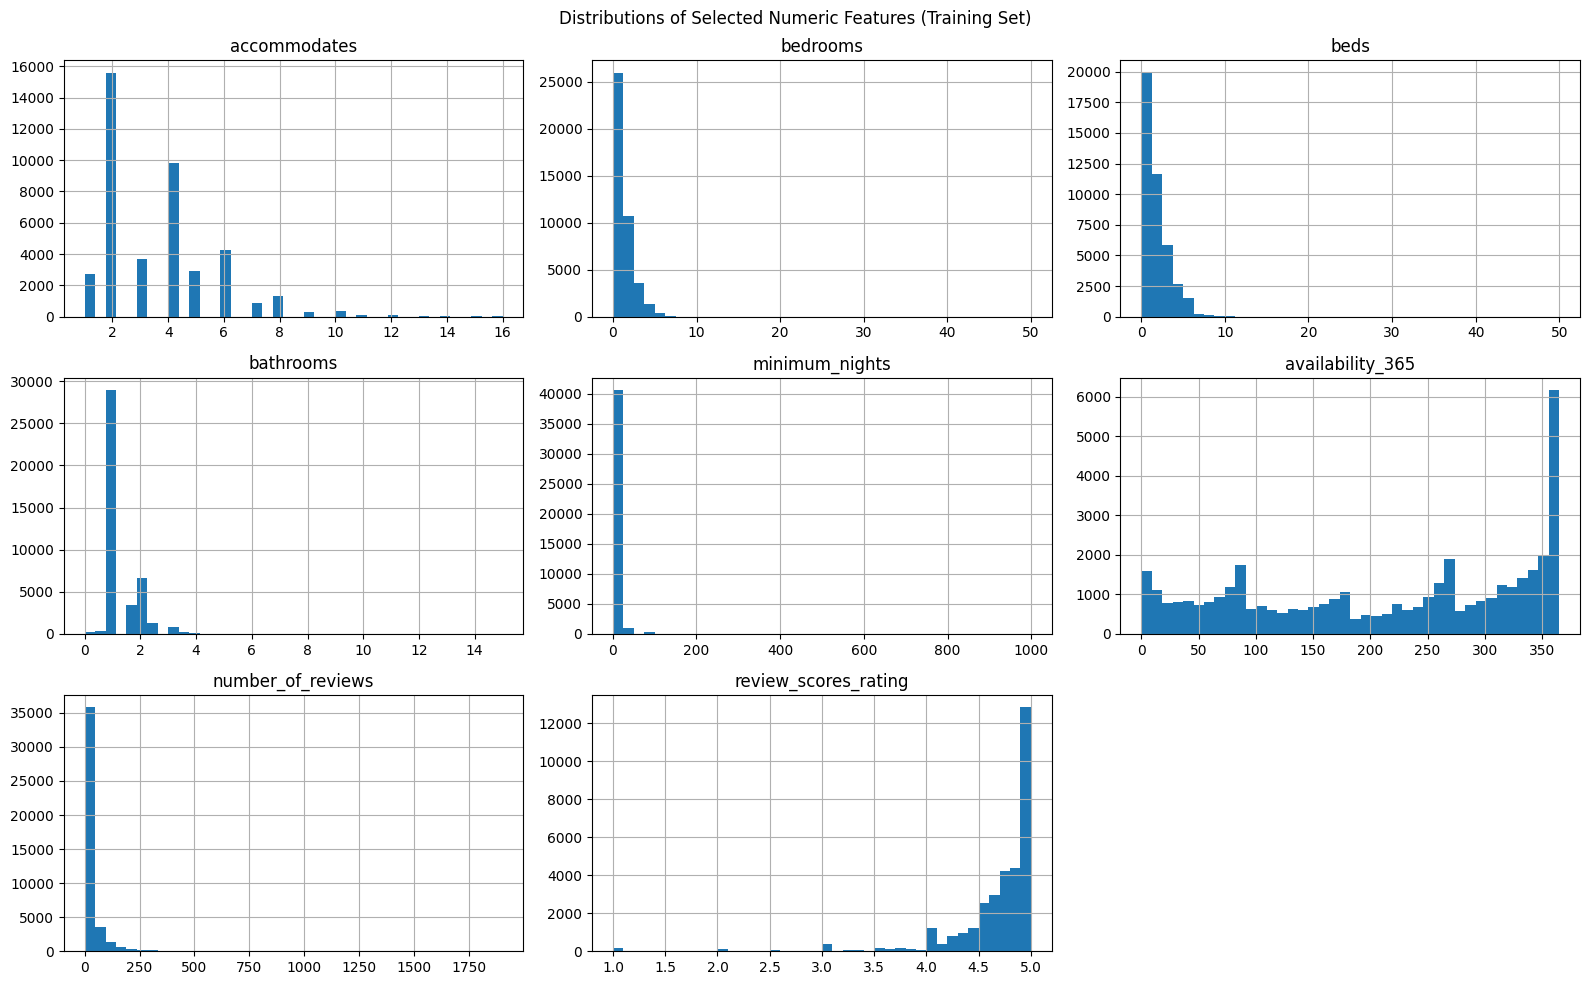

In [116]:
selected_feature_columns = [
    "accommodates", "bedrooms", "beds", "bathrooms",
    "minimum_nights", "availability_365", "number_of_reviews",
    "review_scores_rating",
]
#used llm to help me print all graphs in one
train_df[selected_feature_columns].hist(bins=40, figsize=(16, 10))
plt.suptitle("Distributions of Selected Numeric Features (Training Set)")
plt.tight_layout()
plt.show()


How many unique values
does each non-numeric column (eg.
neighbourhood) have?
`host_identity_verified`	2


`host_has_profile_pic`	2


`room_type`	4


`neighbourhood`	33


`last_review`	1660


`host_name`	9090


`amenities`	38642


`name`	41118


How will you handle these
columns?
I will be removing


>   "license",
    "neighbourhood_group",
    "id",
    "host_id",
    "name",
    "host_name",
    "neighbourhood",
    "last_review"


take Amenities and turned them in to hits or not
and the location to center of london


In [115]:
non_numeric_columns = train_df.select_dtypes(exclude="number").columns
unique_value_counts = train_df[non_numeric_columns].nunique().sort_values()
display(unique_value_counts)

,0
host_identity_verified,2
host_has_profile_pic,2
room_type,4
neighbourhood,33
last_review,1660
host_name,9090
amenities,38642
name,41118


3: CS 562
--
Is there a relationship between the price and
minimum_nights columns?
the correlation is positive but is super small is about 0.03 and the pairplot shows no visible trend

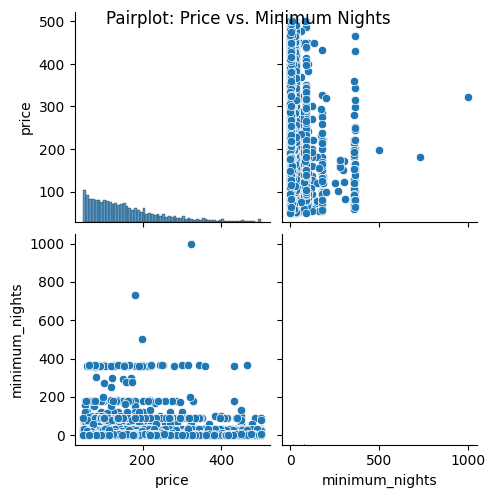

Pearson correlation(price, minimum_nights): 0.032336063826619174


In [128]:
#Consider a pairplot for this.
import seaborn as sns

sns.pairplot(train_df[["price", "minimum_nights"]])
plt.suptitle("Pairplot: Price vs. Minimum Nights")
plt.show()
#getting correlation
correlation = train_df["price"].corr(train_df["minimum_nights"])
print(f"Pearson correlation(price, minimum_nights): {correlation}")

Capping minimum nights makes the pattern easier to see.

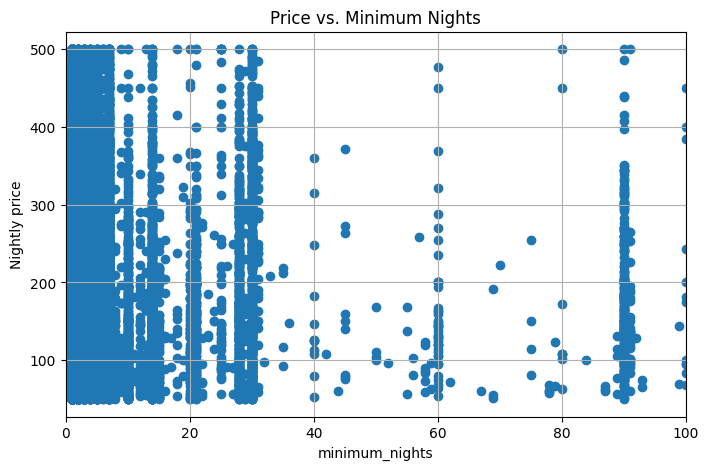

In [134]:
plt.figure(figsize=(8, 5))
plt.scatter(train_df["minimum_nights"], train_df["price"])
#capping at 100 nights min
plt.xlim(0, 100)
plt.xlabel("minimum_nights")
plt.ylabel("Nightly price")
plt.title("Price vs. Minimum Nights")
plt.grid(True)
plt.show()

# Data cleansing / Feature Engineering

In [177]:

#remove unusable columns
columns_to_drop = [
    "license",
    "neighbourhood_group",
    "id",
    "host_id",
    "name","calculated_host_listings_count",
    "host_name","host_identity_verified",
    "neighbourhood","host_has_profile_pic",
    "last_review", "host_total_listings_count"
]
drop_test_df = test_df.drop(columns=columns_to_drop)
drop_train_df = train_df.drop(columns=columns_to_drop)
#dropping all data taht equates to NaN to get usable data
clean_train_df = drop_train_df.dropna(axis=1, how="all").dropna()
clean_test_df = drop_test_df.dropna(axis=1, how="all").dropna()
display(clean_train_df.head())
display(clean_test_df.head())


,latitude,longitude,room_type,minimum_nights,availability_365,number_of_reviews_ltm,accommodates,bathrooms,bedrooms,beds,amenities,availability_30,availability_60,availability_90,number_of_reviews,reviews_per_month,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,price
0,51.473060,-0.183720,Entire home/apt,2,1,6,2,1.5,1.0,1.0,"[""Clothing storage: wardrobe"", ""Self check-in""...",0,0,0,31,1.06,4.71,4.71,4.58,4.65,4.87,4.77,4.65,104
1,51.461770,-0.121320,Entire home/apt,28,319,3,4,1.0,1.0,2.0,"[""Kitchen"", ""Cleaning products"", ""Smoke alarm""...",30,60,90,3,0.32,5.00,5.00,5.00,5.00,5.00,5.00,5.00,219
2,51.545587,-0.058349,Private room,1,365,4,3,1.0,1.0,2.0,"[""Clothing storage: wardrobe"", ""Safe"", ""HDTV w...",30,60,90,4,0.86,4.00,4.25,4.00,4.25,4.50,4.00,4.00,96
4,51.498470,-0.013030,Entire home/apt,1,354,6,4,2.0,2.0,2.0,"[""Self check-in"", ""Kitchen"", ""Smoke alarm"", ""D...",19,49,79,17,0.87,4.82,4.82,5.00,4.65,4.88,4.88,4.82,261
5,51.471330,-0.121890,Entire home/apt,1,360,2,4,1.0,1.0,1.0,"[""Washer"", ""TV"", ""Kitchen"", ""Self check-in"", ""...",25,55,85,2,0.45,5.00,4.50,4.50,5.00,4.50,5.00,4.00,156


,latitude,longitude,room_type,minimum_nights,availability_365,number_of_reviews_ltm,accommodates,bathrooms,bedrooms,beds,amenities,availability_30,availability_60,availability_90,number_of_reviews,reviews_per_month,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value
0,51.626248,-0.141629,Entire home/apt,5,206,2,6,2.0,3,3,"[""Kitchen"", ""Outdoor dining area"", ""HDTV with ...",0,0,0,4,0.30,5.00,5.00,5.00,4.75,5.00,5.00,5.00
1,51.428070,-0.056650,Entire home/apt,2,364,0,2,0.0,0,1,"[""Coffee maker"", ""Kitchen"", ""Dishes and silver...",29,59,89,9,0.09,5.00,5.00,4.89,5.00,5.00,5.00,5.00
2,51.520461,-0.136611,Entire home/apt,5,271,3,5,1.0,2,3,"[""Kitchen"", ""Cleaning products"", ""Smoke alarm""...",3,21,35,3,0.68,3.33,4.00,3.67,4.00,3.67,4.00,3.33
3,51.513179,-0.135828,Entire home/apt,3,288,1,4,1.0,1,2,"[""Self check-in"", ""Kitchen"", ""Shampoo"", ""High ...",7,18,31,1,0.46,5.00,5.00,5.00,5.00,5.00,5.00,5.00
4,51.551530,-0.122166,Entire home/apt,1,301,14,10,2.0,3,5,"[""Kitchen"", ""Cleaning products"", ""Outdoor dini...",13,28,46,14,3.28,4.71,4.64,4.57,4.57,4.71,4.79,4.79


**Engineer Features**


1.   Amenity change 0 or 1 depending on the amenity
2.   Location to center of london
3.   marks never reviewed listings



In [229]:
from scipy.sparse import data
#Engineering features -- adding amenity count adding usually value to property
AMENITY_KEYWORDS = [
    "pool", "hot tub", "gym", "elevator", "dishwasher", "dryer",
    "free parking", "bathtub", "balcony", "garden",
]

#From Google: The coordinates 51° North and 0° (Longitude) pinpoint London, United Kingdom
LONDON_LATITUDE = 51
LONDON_LONGITUDE = 0


#making engineer function to
def engineer_features(listings_df):
    """Return a copy of listings_df with engineered feature columns added."""
    #makes copy for munipulation
    engineered_df = listings_df.copy()

    # Amenities are stored as one long quoted string; commas separate items.
    engineered_df["amenities_count"] = (
        engineered_df["amenities"].str.count(",") + 1
    )

    # **** used llm (claude to get a hit if the word is there or not)****
    for keyword in AMENITY_KEYWORDS:
        flag_column = "has_" + keyword.replace(" ", "_")
        engineered_df[flag_column] = (
            engineered_df["amenities"]
            .str.contains(keyword, case=False)
            .astype(int)
        )

    # checking the distance from the center of london
    engineered_df["distance_to_centre"] = engineered_df.apply(
        lambda row: (
            (row["latitude"] - LONDON_LATITUDE) ** 2
            + (row["longitude"] - LONDON_LONGITUDE) ** 2
        ) ** 0.5,
        axis=1,
    )
    # marks never reviewed listings
    engineered_df["has_reviews"] = (engineered_df["review_scores_rating"].notna().astype(int))

    return engineered_df

eng_train_df = engineer_features(clean_train_df)
eng_test_df = engineer_features(clean_test_df)
#print current data before cleaning
display(eng_train_df[["amenities_count", "distance_to_centre", "has_reviews"]].head())


,amenities_count,distance_to_centre,has_reviews
0,55,0.507483,1
1,39,0.477441,1
2,44,0.548698,1
4,30,0.498640,1
5,8,0.486836,1


Select Features And Target

In [243]:
#sets 1 if it has the features
AMENITY_FLAG_COLUMNS = ["has_" + kw.replace(" ", "_") for kw in AMENITY_KEYWORDS]

NUMERIC_FEATURE_COLUMNS = [
    "accommodates", "bedrooms", "bathrooms", "minimum_nights",
    "latitude", "longitude", "distance_to_centre",
    "availability_30", "availability_60", "availability_90",
    "availability_365", "number_of_reviews", "number_of_reviews_ltm",
    "reviews_per_month", "review_scores_rating", "review_scores_location",
    "review_scores_cleanliness", "review_scores_value",
    "amenities_count", "has_reviews",
] + AMENITY_FLAG_COLUMNS

#type of room anf the neighbourhood
CATEGORICAL_FEATURE_COLUMNS = ["room_type"]
TARGET_COLUMN = "price"

print(f"{len(NUMERIC_FEATURE_COLUMNS)} numeric features, "
      f"{len(CATEGORICAL_FEATURE_COLUMNS)} categorical features")
print("Target:", TARGET_COLUMN)

30 numeric features, 1 categorical features
Target: price


# Model preparation

Train and validation split
We evaluate models on data they did not train on


```
# TODO: Split X and y into train and test sets.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
```



In [232]:
#split 75/25 into an internal training set and a validation set
internal_train_df, validation_df = train_test_split(
    eng_train_df, test_size=0.25,random_state=42, stratify = eng_train_df[TARGET_COLUMN]
)
print("Training rows:", len(internal_train_df))
print("Testing rows:", len(validation_df))

Training rows: 24766
Testing rows: 8256


##Fit The Preprocessing On The Training Split Only

Everything that "learns" from data — the imputation medians, the one-hot
encoder, the location K-Means — is fitted on the internal training split
only, then applied unchanged to the validation split (and later the test
file). That way nothing about held-out data leaks into fitting.

The K-Means step clusters listings by scaled latitude/longitude into
geographic zones.

In [246]:
# Calculate medians for numeric features from the training set
numeric_medians = internal_train_df[NUMERIC_FEATURE_COLUMNS].median()

"""Initialize and fit the OneHotEncoder on the categorical features of the internal training data
handle_unknown="ignore" allows the encoder to safely process any new category in validation/test sets
sparse_output=False ensures a dense array output
Ref: https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html
"""
one_hot_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
one_hot_encoder.fit(internal_train_df[CATEGORICAL_FEATURE_COLUMNS])

# Initialize and fit the StandardScaler on the latitude and longitude of the internal training data
geo_scaler = StandardScaler()
scaled_train_coordinates = geo_scaler.fit_transform(
    internal_train_df[["latitude", "longitude"]]
)

"""Perform K-Means clustering on the scaled geographical coordinates
  (create location-based clusters)
"""
location_kmeans = KMeans(n_clusters=12, n_init=10, random_state=42)
location_kmeans.fit(scaled_train_coordinates)

#Assemble the numeric + one-hot + geo-cluster model matrix
def build_feature_matrix(listings_df):
    # Fill missing numeric features using medians calculated from the training data
    numeric_features = (
        listings_df[NUMERIC_FEATURE_COLUMNS].fillna(numeric_medians)
    )

    # One-hot encode categorical features
    encoded_categories = pd.DataFrame(
        one_hot_encoder.transform(listings_df[CATEGORICAL_FEATURE_COLUMNS]),
        index=listings_df.index,
        columns=one_hot_encoder.get_feature_names_out(
            CATEGORICAL_FEATURE_COLUMNS
        ),
    )

    # Scale geographical coordinates using the scaler fitted on training data
    scaled_coordinates = geo_scaler.transform(
        listings_df[["latitude", "longitude"]]
    )
    # Predict cluster labels for geographical locations using the KMeans model fitted on training data
    cluster_labels = pd.Series(
        location_kmeans.predict(scaled_coordinates),
        index=listings_df.index,
    )
    # Convert cluster labels into one-hot encoded indicator variables
    cluster_indicators = pd.get_dummies(cluster_labels, prefix="geo_cluster")

    # Concatenate all feature types (numeric, one-hot encoded categorical, geo-cluster indicators)
    return pd.concat(
        [numeric_features, encoded_categories, cluster_indicators], axis=1
    )


# Build feature matrices for the internal training and validation sets
X_train = build_feature_matrix(internal_train_df)
X_validation = build_feature_matrix(validation_df).reindex(
    columns=X_train.columns, fill_value=0
)

# Assign target variables for training and validation sets
y_train = internal_train_df[TARGET_COLUMN]
y_validation = validation_df[TARGET_COLUMN]

print("Feature matrix shape:", X_train.shape)

Feature matrix shape: (24766, 46)


# Model

RMSE (root mean squared error) is the score used for every model it is in the same units as the target, so an RMSE of 64 means the predictions are off by about that on a typical listing.

In [255]:
#rmse -- average magnitude of errors between predicted and actual values
def validation_rmse(fitted_model, feature_matrix, true_prices):
    """Return the root-mean-squared error of a fitted model."""
    predictions = fitted_model.predict(feature_matrix)
    return mean_squared_error(true_prices, predictions) ** 0.5


rmse_results = {}

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

rmse_results["Linear Regression"] = validation_rmse( linear_model, X_validation, y_validation)
print(f"Linear Regression validation RMSE: "
      f"${rmse_results['Linear Regression']:.2f}")

Linear Regression validation RMSE: $62.72


Model CART


In [280]:

from sklearn.tree import DecisionTreeRegressor

depth_results = []
for max_depth in range(1, 19):
    depth_tree = DecisionTreeRegressor(
        max_depth=max_depth,
        min_samples_leaf=15,
        random_state=42,
    )
    depth_tree.fit(X_train, y_train)
    depth_results.append({
        "max_depth": max_depth,
        "train_rmse": validation_rmse(depth_tree, X_train, y_train),
        "validation_rmse": validation_rmse(
            depth_tree, X_validation, y_validation
        ),
    })

In [281]:
#Train a baseline CART model (Regression)
baseline_tree = DecisionTreeRegressor(max_depth=3, random_state=42)
baseline_tree.fit(X_train, y_train)

print("Baseline tree depth:", baseline_tree.get_depth())
print("Baseline tree leaves:", baseline_tree.get_n_leaves())

# Evaluate the baseline model using RMSE (for regression)
rmse_baseline = validation_rmse(baseline_tree, X_validation, y_validation)
print(f"Baseline Decision Tree validation RMSE: ${rmse_baseline:.2f}")

depth_results = pd.DataFrame(depth_results)
display(depth_results.round(2))

Baseline tree depth: 3
Baseline tree leaves: 8
Baseline Decision Tree validation RMSE: $70.02


,max_depth,train_rmse,validation_rmse
0,1,80.71,79.51
1,2,73.47,72.38
2,3,70.65,70.02
3,4,68.47,68.33
4,5,65.82,66.43
5,6,63.30,64.40
6,7,60.68,62.79
7,8,58.33,62.57
8,9,56.14,62.63
9,10,54.17,62.62


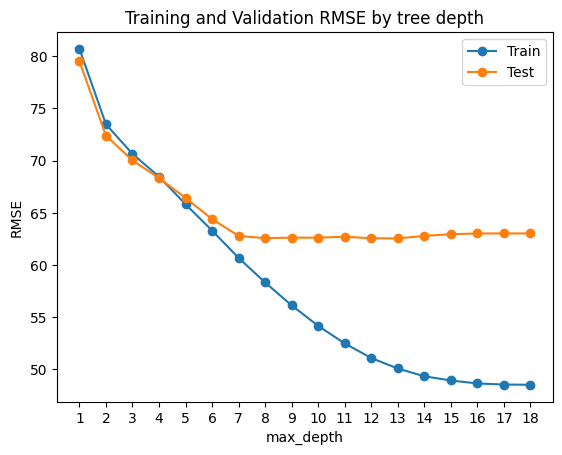

In [283]:
plt.plot(depth_results["max_depth"], depth_results["train_rmse"], marker="o", label="Train")
plt.plot(depth_results["max_depth"], depth_results["validation_rmse"], marker="o", label="Test")
plt.xticks(range(1, 19))
plt.xlabel("max_depth")
plt.ylabel("RMSE")
plt.title("Training and Validation RMSE by tree depth")
plt.legend()
plt.show()